<a href="https://colab.research.google.com/github/vis-hal-git/Blood-Cancer-Prediction/blob/main/Model_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mehradaria/leukemia")

100%|██████████| 110M/110M [00:00<00:00, 137MB/s] 

Extracting files...


In [ ]:
import os

base_dir = os.path.join(path, "Segmented")  # Recommended

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

base_dir = os.path.join(path, "Segmented")   # Recommended

new_base = "/content/leukemia_split"
os.makedirs(new_base, exist_ok=True)

for category in os.listdir(base_dir):
    category_path = os.path.join(base_dir, category)
    images = os.listdir(category_path)

    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    for split_name, split_data in zip(["train","val","test"], [train,val,test]):
        split_folder = os.path.join(new_base, split_name, category)
        os.makedirs(split_folder, exist_ok=True)

        for img in split_data:
            shutil.copy(
                os.path.join(category_path, img),
                os.path.join(split_folder, img)
            )

print("Dataset Split Completed")

Dataset Split Completed


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_dir = os.path.join(new_base, "train")
val_dir = os.path.join(new_base, "val")
test_dir = os.path.join(new_base, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2277 images belonging to 4 classes.
Found 489 images belonging to 4 classes.
Found 490 images belonging to 4 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.6171875), 1: np.float64(0.8261973875181422), 2: np.float64(0.8445845697329377), 3: np.float64(1.012900355871886)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.5117 - loss: 1.1132

72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 598ms/step - accuracy: 0.5133 - loss: 1.1105 - val_accuracy: 0.1554 - val_loss: 1.5128 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.7561 - loss: 0.6842

72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 435ms/step - accuracy: 0.7561 - loss: 0.6838 - val_accuracy: 0.2229 - val_loss: 1.2942 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8049 - loss: 0.5686

72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 426ms/step - accuracy: 0.8047 - loss: 0.5687 - val_accuracy: 0.5521 - val_loss: 1.1226 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.7906 - loss: 0.5717

72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 444ms/step - accuracy: 0.7905 - loss: 0.5714 - val_accuracy: 0.5951 - val_loss: 0.9125 - learning_rate: 1.0000e-04
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8143 - loss: 0.5074

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 430ms/step - accuracy: 0.8419 - loss: 0.4494 - val_accuracy: 0.8364 - val_loss: 0.4019 - learning_rate: 1.0000e-04
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8280 - loss: 0.4317

72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 447ms/step - accuracy: 0.8280 - loss: 0.4319 - val_accuracy: 0.8487 - val_loss: 0.3835 - learning_rate: 1.0000e-04
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 424ms/step - accuracy: 0.8431 - loss: 0.4416 - val_accuracy: 0.8528 - val_loss: 0.3840 - learning_rate: 1.0000e-04
Epoch 13/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8450 - loss: 0.4296

72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 435ms/step - accuracy: 0.8450 - loss: 0.4296 - val_accuracy: 0.8466 - val_loss: 0.3692 - learning_rate: 1.0000e-04
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 420ms/step - accuracy: 0.8547 - loss: 0.3957 - val_accuracy: 0.8528 - val_loss: 0.3814 - learning_rate: 1.0000e-04
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 414ms/step - accuracy: 0.8496 - loss: 0.4021 - val_accuracy: 0.8425 - val_loss: 0.3734 - learning_rate: 1.0000e-04
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 426ms/step - accuracy: 0.8667 - loss: 0.3955 - val_accuracy: 0.8528 - val_loss: 0.3803 - learning_rate: 1.0000e-04
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.8428 - loss: 0.4053

72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 415ms/step - accuracy: 0.8430 - loss: 0.4052 - val_accuracy: 0.8507 - val_loss: 0.3629 - learning_rate: 3.0000e-05
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.8568 - loss: 0.3770

72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 418ms/step - accuracy: 0.8567 - loss: 0.3772 - val_accuracy: 0.8569 - val_loss: 0.3530 - learning_rate: 3.0000e-05
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 411ms/step - accuracy: 0.8598 - loss: 0.3959 - val_accuracy: 0.8507 - val_loss: 0.3596 - learning_rate: 3.0000e-05
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 417ms/step - accuracy: 0.8459 - loss: 0.4162 - val_accuracy: 0.8528 - val_loss: 0.3553 - learning_rate: 3.0000e-05


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 68s 597ms/step - accuracy: 0.6767 - loss: 1.0827 - val_accuracy: 0.4335 - val_loss: 3.0729
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 418ms/step - accuracy: 0.7715 - loss: 0.6260 - val_accuracy: 0.4744 - val_loss: 4.8650
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 442ms/step - accuracy: 0.8274 - loss: 0.5247 - val_accuracy: 0.5583 - val_loss: 3.8076
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 444ms/step - accuracy: 0.8436 - loss: 0.4385 - val_accuracy: 0.5808 - val_loss: 2.2796
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 436ms/step - accuracy: 0.8528 - loss: 0.4281 - val_accuracy: 0.7546 - val_loss: 0.6829
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 543ms/step - accuracy: 0.8469 - loss: 0.4018 - val_accuracy: 0.8630 - val_loss: 0.3708
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 432ms/step - accuracy: 0.8731 - loss: 0.3469 - val_accuracy: 0.8630 - val_loss: 0.4083
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 424ms/step - accuracy: 0.8739 - loss: 0.3634 - val_accu

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 461ms/step
              precision    recall  f1-score   support

           0       0.93      0.55      0.69        76
           1       0.82      0.93      0.87       148
           2       0.88      0.94      0.91       145
           3       0.96      0.96      0.96       121

    accuracy                           0.88       490
   macro avg       0.90      0.85      0.86       490
weighted avg       0.89      0.88      0.88       490



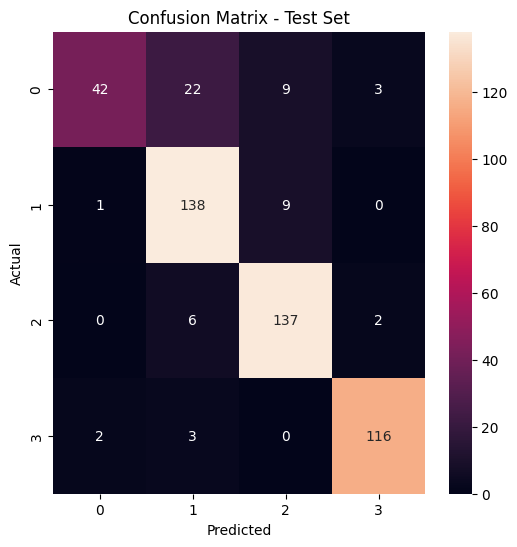

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
pred = model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)

print(classification_report(test_gen.classes, y_pred))

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

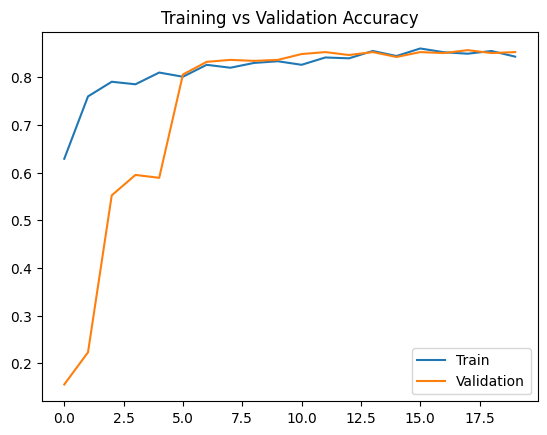

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [ ]:
print("Best Validation Accuracy:", max(history.history['val_accuracy']))

Best Validation Accuracy: 0.8568507432937622
